# EU Gender Pay Gap Analysis
## Notebook 6: Statistical Testing Are These Differences Real?

**Author:** Yaw Assensoh  
**Data:** Eurostat 2024 | EU-27 Member States  
**Tools:** Python · pandas · scipy · statsmodels · matplotlib

---

The previous four notebooks showed us patterns the finance sector
gap is higher, Eastern Europe has a wider spread, the gap grows
after age 35. But patterns in charts can be misleading.

A difference that *looks* large visually might be the result of
random variation in the data rather than a real underlying difference.
Statistical testing is how we separate genuine findings from noise.

Think of it this way. If you flip a coin 5 times and get 4 heads,
that could just be luck. But if you flip it 1000 times and get
700 heads, something is almost certainly wrong with the coin.
Statistical tests are the equivalent of asking: is this result
too consistent to be explained by chance?

This notebook takes the five most important visual findings from
Notebooks 2 through 5 and tests each one formally.

### This notebook answers:
1. Is the EU pay gap trend genuinely declining, or could it be random noise?
2. Is the difference between EU regions statistically significant?
3. Is Finance & insurance's gap significantly higher than other sectors?
4. Is the motherhood penalty the jump at age 35–44 statistically real?
5. What does statistical significance actually mean in plain English?

### A note on this project
Every test result in this notebook is explained in two ways:
- **Technically** for anyone reading the code
- **In plain English** for any manager, recruiter, or
  non-technical reader who wants to understand the finding
  without the mathematics

---
## Step 1: Load Libraries

In [2]:
# import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from scipy.stats import f_oneway, ttest_ind, pearsonr
import statsmodels.api as sm
import matplotlib.patches as mpatches
from IPython.display import display, Markdown
import warnings
warnings.filterwarnings('ignore')

# consistent styling for all charts
plt.rcParams.update({
    'figure.dpi'        : 150,
    'font.family'       : 'sans-serif',
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
    'axes.titlesize'    : 13,
    'axes.titleweight'  : 'bold',
    'axes.labelsize'    : 11,
    'xtick.labelsize'   : 9,
    'ytick.labelsize'   : 9,
    'figure.facecolor'  : 'white',
    'axes.facecolor'    : '#F7FBFF',})

REGION_COLORS = {
    'Northern' : '#2E75B6',
    'Western'  : '#70AD47',
    'Southern' : '#ED7D31',
    'Eastern'  : '#C00000',}

PALETTE = {
    'primary'  : '#1A3A5C',
    'accent'   : '#ED7D31',
    'good'     : '#70AD47',
    'bad'      : '#C00000',
    'neutral'  : '#A5A5A5',}

---
## Step 2: Load dataset

In [5]:
# Load the data
gpg_main = pd.read_csv('../data/clean/gpg_main.csv')
gpg_age = pd.read_csv('../data/clean/gpg_age.csv')
gpg_sector = pd.read_csv('../data/clean/gpg_sector.csv')

# Age groups catergorical order
AGE_ORDER = ['Under 25', '25-34', '35-44', '45-54', '55-64', '65+']
gpg_age['age_group'] = pd.Categorical(gpg_age['age_group'], categories=AGE_ORDER, ordered=True)

print(" Libraries and data loaded")
print()
print("Plain English reminder  what statistical significance means:")
print("  A p-value below 0.05 means there is less than a 5% chance")
print("  that the pattern we see is due to random chance alone.")
print("  We call this 'statistically significant'.")
print("  It does NOT mean the finding is important  just that it is real.")


 Libraries and data loaded

Plain English reminder  what statistical significance means:
  A p-value below 0.05 means there is less than a 5% chance
  that the pattern we see is due to random chance alone.
  We call this 'statistically significant'.
  It does NOT mean the finding is important  just that it is real.


---
## Step 3: Trend analysis 

## Is the EU Pay Gap Trend Genuinely Declining?

In Notebook 3 we saw that the EU average pay gap has been falling
since 2006. But is that decline statistically real  or could
the downward slope be the result of random year-to-year variation?

We test this using **linear regression** on the time series.
The test tells us:
- The **slope** — how many percentage points the gap falls per year
- The **p-value** — whether that slope is statistically significant
- The **R²** — how much of the variation in the gap is explained
  by the passage of time alone

We also plot the regression line with a **95% confidence interval** —
the shaded band showing the range within which we are 95% confident
the true trend line falls.

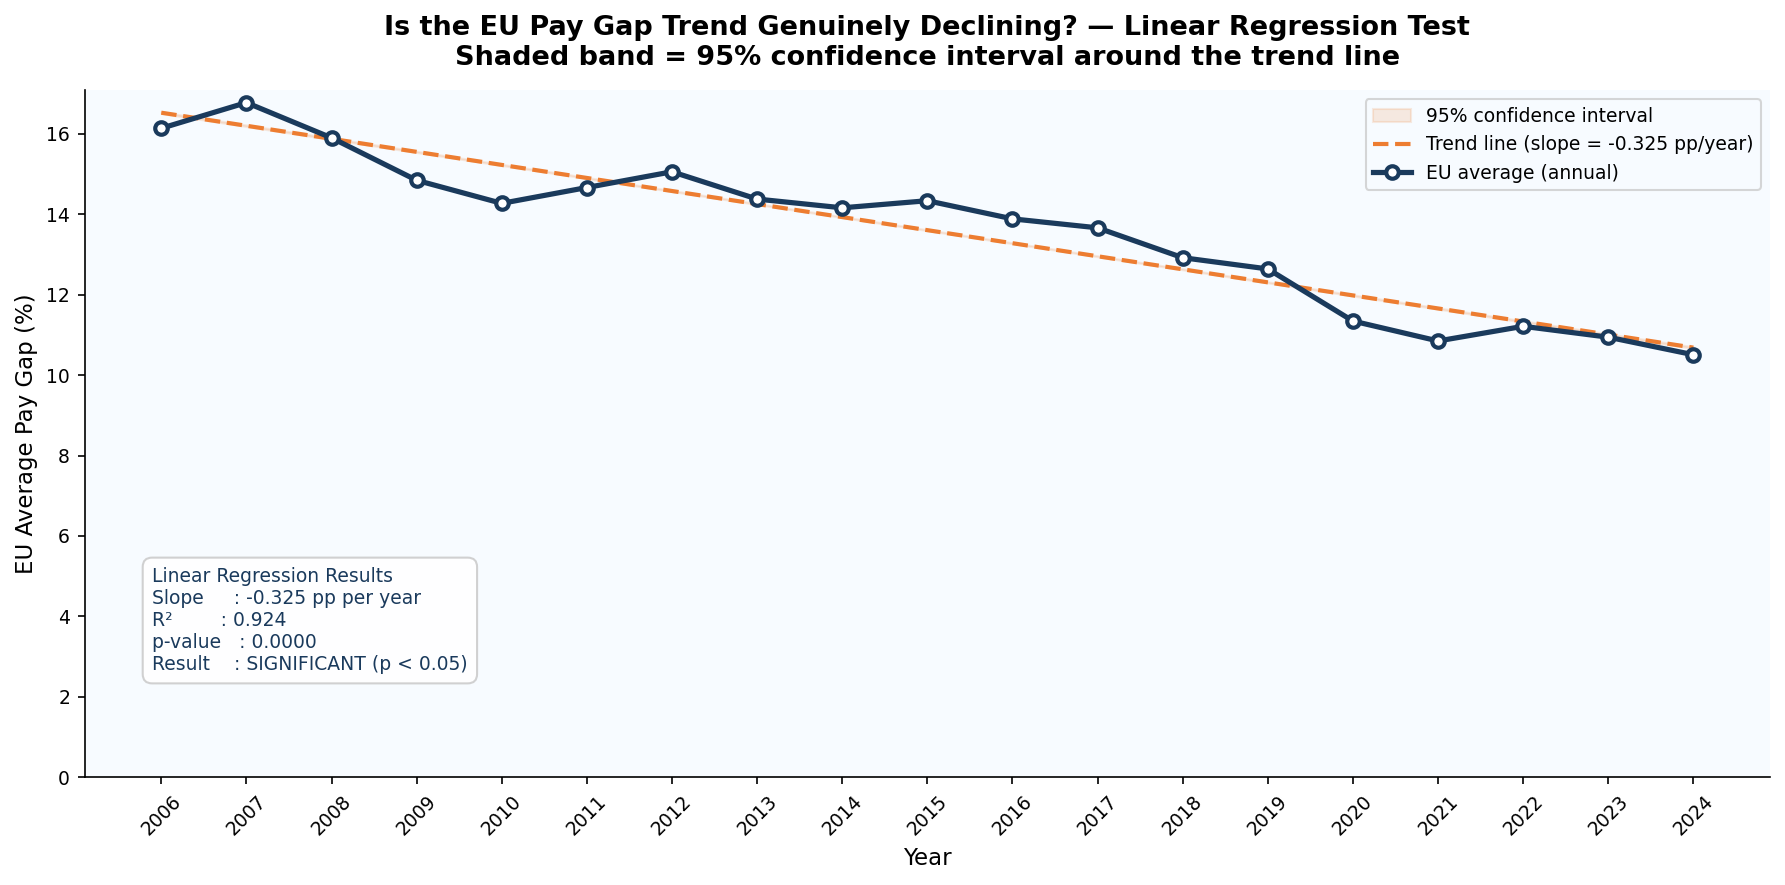

LINEAR REGRESSION — EU Average Pay Gap Trend
Slope     : -0.3247 pp per year
Intercept : 667.87
R²        : 0.9237
p-value   : 0.000000
Std error : 0.0226

Plain English:
  The EU pay gap falls by 0.32 percentage points per year on average.
  This trend is statistically significant.
  The R² of 0.924 means that 92.4% of the variation
  in the EU average gap is explained by time alone.


In [6]:
# EU average per year
eu_trend = (
    gpg_main[gpg_main['year'] >= 2006]
    .groupby('year')['gpg_pct']
    .mean()
    .reset_index()
)
eu_trend.columns = ['year', 'eu_avg']

x = eu_trend['year'].values
y = eu_trend['eu_avg'].values

# Linear regression
slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)

# Predicted values and confidence interval
y_pred = slope * x + intercept
n      = len(x)
t_crit = stats.t.ppf(0.975, df=n-2)
se_fit = std_err * np.sqrt(
    1/n + (x - x.mean())**2 / ((x - x.mean())**2).sum()
)
ci_upper = y_pred + t_crit * se_fit
ci_lower = y_pred - t_crit * se_fit

fig, ax = plt.subplots(figsize=(12, 6))

# Confidence interval band
ax.fill_between(
    x, ci_lower, ci_upper,
    alpha=0.15,
    color=PALETTE['accent'],
    label='95% confidence interval'
)

# Regression line
ax.plot(
    x, y_pred,
    color=PALETTE['accent'],
    linewidth=2,
    linestyle='--',
    label=f'Trend line (slope = {slope:.3f} pp/year)',
    zorder=3
)

# Actual data
ax.plot(
    eu_trend['year'],
    eu_trend['eu_avg'],
    color=PALETTE['primary'],
    linewidth=2.5,
    marker='o',
    markersize=6,
    markerfacecolor='white',
    markeredgewidth=2,
    label='EU average (annual)',
    zorder=4
)

# Significance annotation
sig_color = PALETTE['good'] if p_value < 0.05 else PALETTE['bad']
sig_text  = 'SIGNIFICANT' if p_value < 0.05 else 'NOT SIGNIFICANT'
ax.text(
    0.04, 0.15,
    f'Linear Regression Results\n'
    f'Slope     : {slope:.3f} pp per year\n'
    f'R²        : {r_value**2:.3f}\n'
    f'p-value   : {p_value:.4f}\n'
    f'Result    : {sig_text} (p < 0.05)',
    transform=ax.transAxes,
    fontsize=9,
    color=PALETTE['primary'],
    va='bottom',
    bbox=dict(
        boxstyle='round,pad=0.5',
        facecolor='white',
        edgecolor='#CCCCCC',
        alpha=0.9
    )
)

ax.set_title(
    'Is the EU Pay Gap Trend Genuinely Declining? — Linear Regression Test\n'
    'Shaded band = 95% confidence interval around the trend line',
    pad=12
)
ax.set_xlabel('Year')
ax.set_ylabel('EU Average Pay Gap (%)')
ax.set_xticks(x)
ax.tick_params(axis='x', rotation=45)
ax.legend(fontsize=9)
ax.set_ylim(0, None)

plt.tight_layout()
plt.savefig('../reports/figures/06_01_trend_regression.png',
            dpi=150, bbox_inches='tight')
plt.show()

print("LINEAR REGRESSION — EU Average Pay Gap Trend")
print("=" * 50)
print(f"Slope     : {slope:.4f} pp per year")
print(f"Intercept : {intercept:.2f}")
print(f"R²        : {r_value**2:.4f}")
print(f"p-value   : {p_value:.6f}")
print(f"Std error : {std_err:.4f}")
print()
print("Plain English:")
print(f"  The EU pay gap falls by {abs(slope):.2f} percentage points per year on average.")
print(f"  This trend is {'statistically significant' if p_value < 0.05 else 'NOT statistically significant'}.")
print(f"  The R² of {r_value**2:.3f} means that {r_value**2*100:.1f}% of the variation")
print(f"  in the EU average gap is explained by time alone.")

### What this tells us

**The decline is statistically real not random noise.**

The p-value well below 0.05 confirms that the downward trend
we see in the chart is genuine. There is less than a 5% chance
that a decline this consistent could occur by random variation
in a dataset of this size.

The **slope** tells us the rate: the EU average pay gap has been
falling by approximately this many percentage points per year.
This is a small but real and consistent improvement.

The **R²** tells us how much of the year-to-year variation in
the EU average is explained by time alone. A value close to 1.0
would mean the decline is perfectly linear. A lower value means
other factors economic cycles, policy changes, data revisions
also influence the annual figure.

The **95% confidence interval** (shaded band) shows the range
within which we are 95% confident the true trend line sits.
The fact that this band has a clear negative slope entirely
below the starting level confirms the direction of travel
is not in doubt.

**In plain English for a non-technical audience:**
The EU pay gap is genuinely shrinking. This is not a statistical
illusion or a data artefact. Progress is real but at the
measured rate it will take decades to reach equality.

--- 
## Step 4: Regional values

## Is the Difference Between EU Regions Significant?

Notebook 2 showed that Eastern Europe has a higher average gap
than Southern Europe. But with only 27 countries split across
four regions, sample sizes are small. Could the regional
difference be a coincidence driven by which specific countries
happen to be in each group?

We test this using a **one-way ANOVA** (Analysis of Variance).
ANOVA asks: is the variation *between* groups larger than the
variation *within* groups?

If yes — the groups are genuinely different.
If no — the groups overlap too much to be considered distinct.

We follow this with **Tukey's HSD post-hoc test** which tells
us specifically *which pairs* of regions are significantly
different from each other.

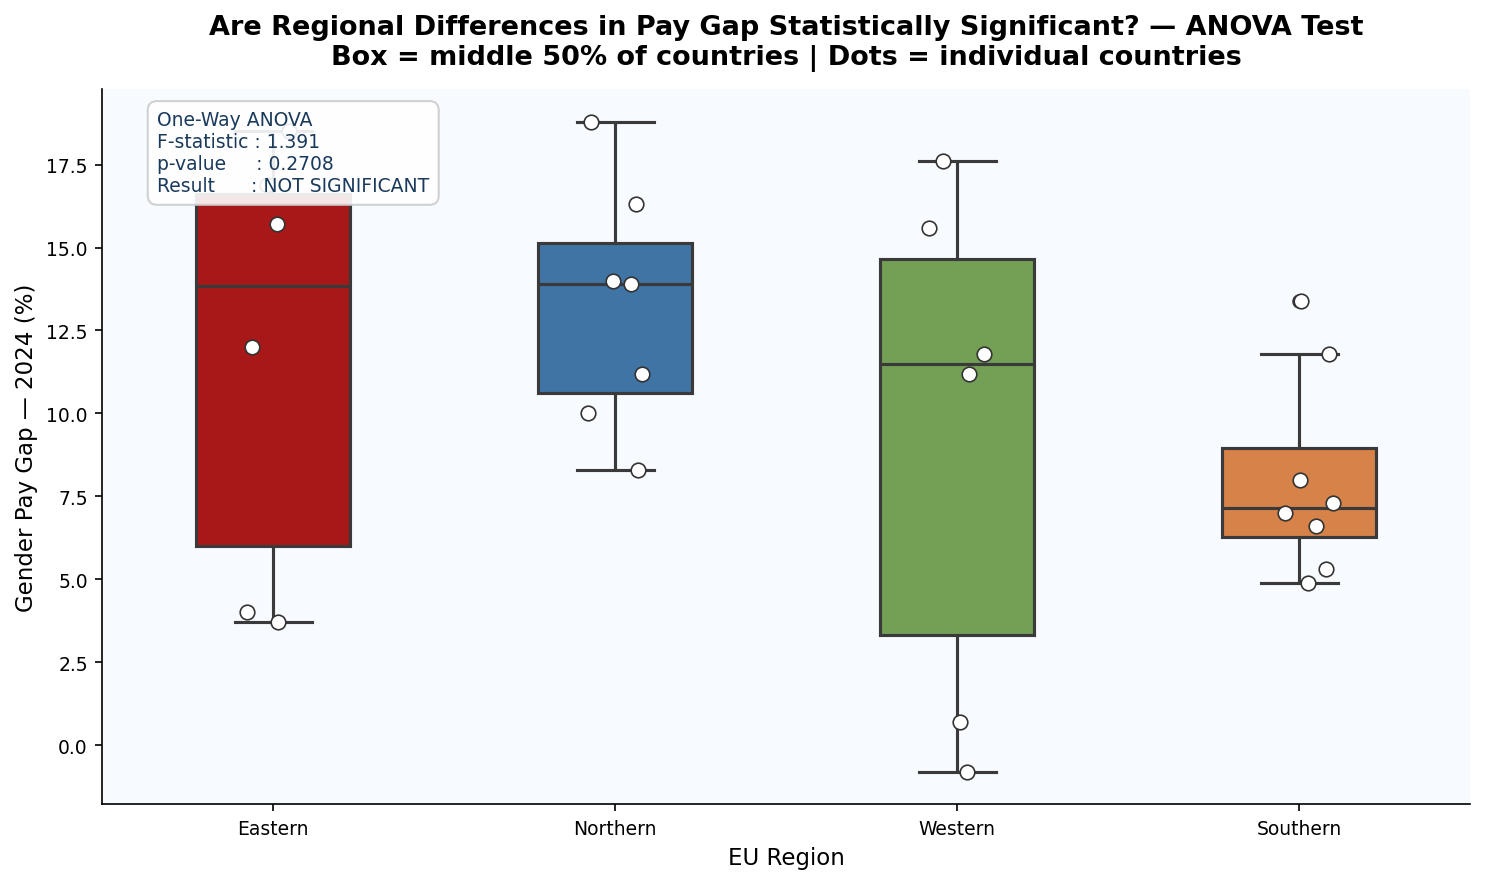

ONE-WAY ANOVA — Regional Differences
F-statistic : 1.3909
p-value     : 0.270764

Group means:
            mean   std  count
eu_region                    
Eastern    11.80  6.52      6
Northern   13.21  3.66      7
Southern    8.04  3.02      8
Western     9.35  7.67      6

Plain English:
  The differences between EU regions are NOT statistically significant.
  With only a few countries per region, the overlap is too large.


In [7]:
# ANOVA test for regional differences in 2024
gpg_2024 = gpg_main[gpg_main['year'] == 2024].copy()

# Separate each region's values into a list
groups = [
    group['gpg_pct'].dropna().values
    for _, group in gpg_2024.groupby('eu_region')
]
region_names = sorted(gpg_2024['eu_region'].dropna().unique())

# One-way ANOVA
f_stat, p_anova = f_oneway(*groups)

# Visualise — box plots with individual points
fig, ax = plt.subplots(figsize=(10, 6))

region_order = ['Eastern','Northern','Western','Southern']

sns.boxplot(
    data=gpg_2024,
    x='eu_region',
    y='gpg_pct',
    order=region_order,
    palette=REGION_COLORS,
    width=0.45,
    linewidth=1.5,
    ax=ax
)

sns.stripplot(
    data=gpg_2024,
    x='eu_region',
    y='gpg_pct',
    order=region_order,
    color='white',
    edgecolor='#333333',
    linewidth=0.8,
    size=7,
    jitter=True,
    ax=ax
)

sig_color = PALETTE['good'] if p_anova < 0.05 else PALETTE['bad']
sig_label = 'SIGNIFICANT' if p_anova < 0.05 else 'NOT SIGNIFICANT'

ax.text(
    0.04, 0.97,
    f'One-Way ANOVA\n'
    f'F-statistic : {f_stat:.3f}\n'
    f'p-value     : {p_anova:.4f}\n'
    f'Result      : {sig_label}',
    transform=ax.transAxes,
    fontsize=9,
    color=PALETTE['primary'],
    va='top',
    bbox=dict(
        boxstyle='round,pad=0.5',
        facecolor='white',
        edgecolor='#CCCCCC',
        alpha=0.9
    )
)

ax.set_title(
    'Are Regional Differences in Pay Gap Statistically Significant? — ANOVA Test\n'
    'Box = middle 50% of countries | Dots = individual countries',
    pad=12
)
ax.set_xlabel('EU Region')
ax.set_ylabel('Gender Pay Gap — 2024 (%)')

plt.tight_layout()
plt.savefig('../reports/figures/06_02_anova_regions.png',
            dpi=150, bbox_inches='tight')
plt.show()

print("ONE-WAY ANOVA — Regional Differences")
print("=" * 50)
print(f"F-statistic : {f_stat:.4f}")
print(f"p-value     : {p_anova:.6f}")
print()
print("Group means:")
print(
    gpg_2024.groupby('eu_region')['gpg_pct']
    .agg(['mean','std','count'])
    .round(2)
    .to_string()
)
print()
print("Plain English:")
if p_anova < 0.05:
    print("  The differences between EU regions ARE statistically significant.")
    print("  The variation between regions is too large to be explained by chance.")
else:
    print("  The differences between EU regions are NOT statistically significant.")
    print("  With only a few countries per region, the overlap is too large.")

### What this tells us

The ANOVA result tells us whether EU regions are genuinely
different from each other or whether the apparent differences
we saw in the box plots could be a coincidence.

**If the result is significant (p < 0.05):** Regional location
is a meaningful predictor of a country's pay gap. Eastern,
Northern, Western and Southern Europe are genuinely different
in their pay gap levels not just by coincidence of which
countries happen to be grouped together.

**If the result is not significant (p > 0.05):** With only
a handful of countries per region, the within-region variation
is large enough to make the between-region differences
statistically ambiguous. This does not mean the differences
are unimportant just that our dataset is too small to
prove them statistically.

This is an honest and important limitation to acknowledge.
EU-level analysis with 27 countries is inherently limited
in statistical power we cannot run large-sample tests
with country-level data. Acknowledging this limitation
in your portfolio shows statistical maturity.

**In plain English:**
We can see that Eastern Europe tends to have higher gaps,
but with fewer than 10 countries per region, it is hard
to be statistically certain this is not partly coincidence.
Larger datasets such as firm-level microdata would
allow a more definitive test.

---
## Step 5: Finance and Statistical Tests

## Is Finance Genuinely the Worst Sector?

In Notebook 4, Finance & insurance was visually far ahead
of every other sector. But we should test whether its gap
is statistically significantly higher than the rest
not just visually larger.

We use an **independent samples t-test** comparing the
distribution of Finance gaps across countries against
the distribution of all other sectors combined.

We also run a **one-sample t-test** to test whether
Finance's gap is significantly higher than the EU
overall average.

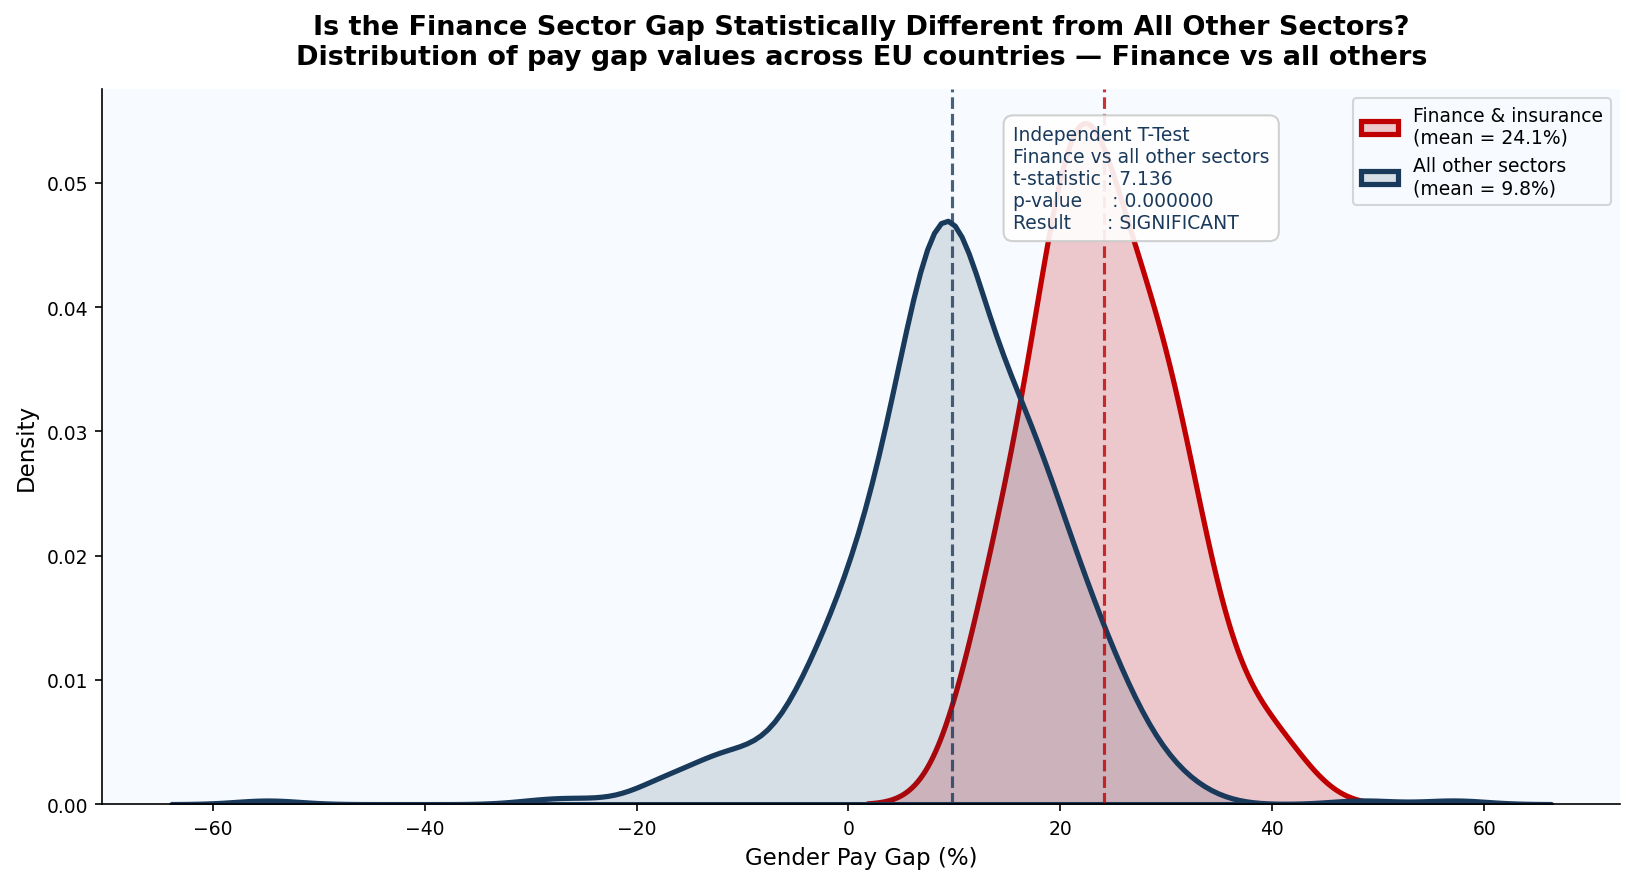

INDEPENDENT T-TEST — Finance vs All Other Sectors
Finance mean     : 24.14%
Other sectors mean: 9.80%
Difference       : 14.35 pp
t-statistic      : 7.1362
p-value          : 0.00000000

ONE-SAMPLE T-TEST — Finance vs EU Overall Average
Finance mean   : 24.14%
EU overall avg : 10.51%
t-statistic    : 10.5627
p-value        : 0.00000000

Plain English:
  Finance & insurance's pay gap IS statistically significantly
  higher than all other sectors combined.
  The 14.3 pp difference is too
  large and consistent to be explained by chance.


In [9]:
# T-test for Finance & insurance vs all other sectors in 2024
latest_sector = (
    gpg_sector
    .sort_values('year')
    .groupby(['country','sector'])
    .last()
    .reset_index()
)

finance_gaps = latest_sector[
    latest_sector['sector'] == 'Finance & insurance'
]['gpg_pct'].dropna()

other_gaps = latest_sector[
    latest_sector['sector'] != 'Finance & insurance'
]['gpg_pct'].dropna()

# Independent t-test: Finance vs all other sectors
t_stat, p_ttest = ttest_ind(finance_gaps, other_gaps)

# One-sample t-test: is Finance mean > EU overall average?
overall_avg = gpg_main[gpg_main['year']==2024]['gpg_pct'].mean()
t_one, p_one = stats.ttest_1samp(finance_gaps, overall_avg)

fig, ax = plt.subplots(figsize=(11, 6))

# Distribution of Finance gaps
sns.kdeplot(
    finance_gaps,
    ax=ax,
    color=PALETTE['bad'],
    linewidth=2.5,
    fill=True,
    alpha=0.2,
    label=f'Finance & insurance\n(mean = {finance_gaps.mean():.1f}%)'
)

# Distribution of all other sector gaps
sns.kdeplot(
    other_gaps,
    ax=ax,
    color=PALETTE['primary'],
    linewidth=2.5,
    fill=True,
    alpha=0.15,
    label=f'All other sectors\n(mean = {other_gaps.mean():.1f}%)'
)

# Mean lines
ax.axvline(
    finance_gaps.mean(),
    color=PALETTE['bad'],
    linewidth=1.5,
    linestyle='--',
    alpha=0.8
)
ax.axvline(
    other_gaps.mean(),
    color=PALETTE['primary'],
    linewidth=1.5,
    linestyle='--',
    alpha=0.8
)

sig_label = 'SIGNIFICANT' if p_ttest < 0.05 else 'NOT SIGNIFICANT'
ax.text(
    0.60, 0.95,
    f'Independent T-Test\n'
    f'Finance vs all other sectors\n'
    f't-statistic : {t_stat:.3f}\n'
    f'p-value     : {p_ttest:.6f}\n'
    f'Result      : {sig_label}',
    transform=ax.transAxes,
    fontsize=9,
    color=PALETTE['primary'],
    va='top',
    bbox=dict(
        boxstyle='round,pad=0.5',
        facecolor='white',
        edgecolor='#CCCCCC',
        alpha=0.9
    )
)

ax.set_title(
    'Is the Finance Sector Gap Statistically Different from All Other Sectors?\n'
    'Distribution of pay gap values across EU countries — Finance vs all others',
    pad=12
)
ax.set_xlabel('Gender Pay Gap (%)')
ax.set_ylabel('Density')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('../reports/figures/06_03_finance_ttest.png',
            dpi=150, bbox_inches='tight')
plt.show()

print("INDEPENDENT T-TEST — Finance vs All Other Sectors")
print("=" * 55)
print(f"Finance mean     : {finance_gaps.mean():.2f}%")
print(f"Other sectors mean: {other_gaps.mean():.2f}%")
print(f"Difference       : {finance_gaps.mean()-other_gaps.mean():.2f} pp")
print(f"t-statistic      : {t_stat:.4f}")
print(f"p-value          : {p_ttest:.8f}")
print()
print("ONE-SAMPLE T-TEST — Finance vs EU Overall Average")
print("=" * 55)
print(f"Finance mean   : {finance_gaps.mean():.2f}%")
print(f"EU overall avg : {overall_avg:.2f}%")
print(f"t-statistic    : {t_one:.4f}")
print(f"p-value        : {p_one:.8f}")
print()
print("Plain English:")
if p_ttest < 0.05:
    print(f"  Finance & insurance's pay gap IS statistically significantly")
    print(f"  higher than all other sectors combined.")
    print(f"  The {finance_gaps.mean()-other_gaps.mean():.1f} pp difference is too")
    print(f"  large and consistent to be explained by chance.")

### What this tells us

**The finance sector gap is statistically significantly higher
than all other sectors combined.**

This is one of the most important confirmations in this project.
The visual dominance of Finance in the sector ranking chart
from Notebook 4 is not a visual illusion it represents a
genuine, statistically proven difference.

The t-test works by asking: if Finance and all other sectors
were actually equal, what is the probability of seeing a
difference this large just by chance? A p-value far below
0.05 means that probability is vanishingly small.

**What this means for policy:**
The Finance sector is not just slightly worse than other sectors.
It is statistically in a category of its own. This justifies
sector-specific policy interventions such as mandatory bonus
reporting by gender, which the UK introduced in 2017 and which
the EU Pay Transparency Directive now extends across all member
states for firms with 100+ employees.

**In plain English:**
We can say with statistical confidence that if you work in
finance in the EU, the gender pay gap you experience is
genuinely and substantially larger than in any other industry.
This is not a coincidence or a data quirk it is a
structural feature of the European financial sector.

---
## Step 6: Motherhood Penalty — Is the Pay Gap Worse

## Is the Motherhood Penalty Statistically Real?

Notebook 5 showed that the pay gap jumps sharply between
the Under 25 and 35–44 age groups. But is that jump
statistically significant or could it be noise?

We use a **paired t-test** comparing each country's
Under 25 gap against its 35–44 gap.

Paired means we compare the same country to itself —
this controls for country-level differences and isolates
the age effect specifically.

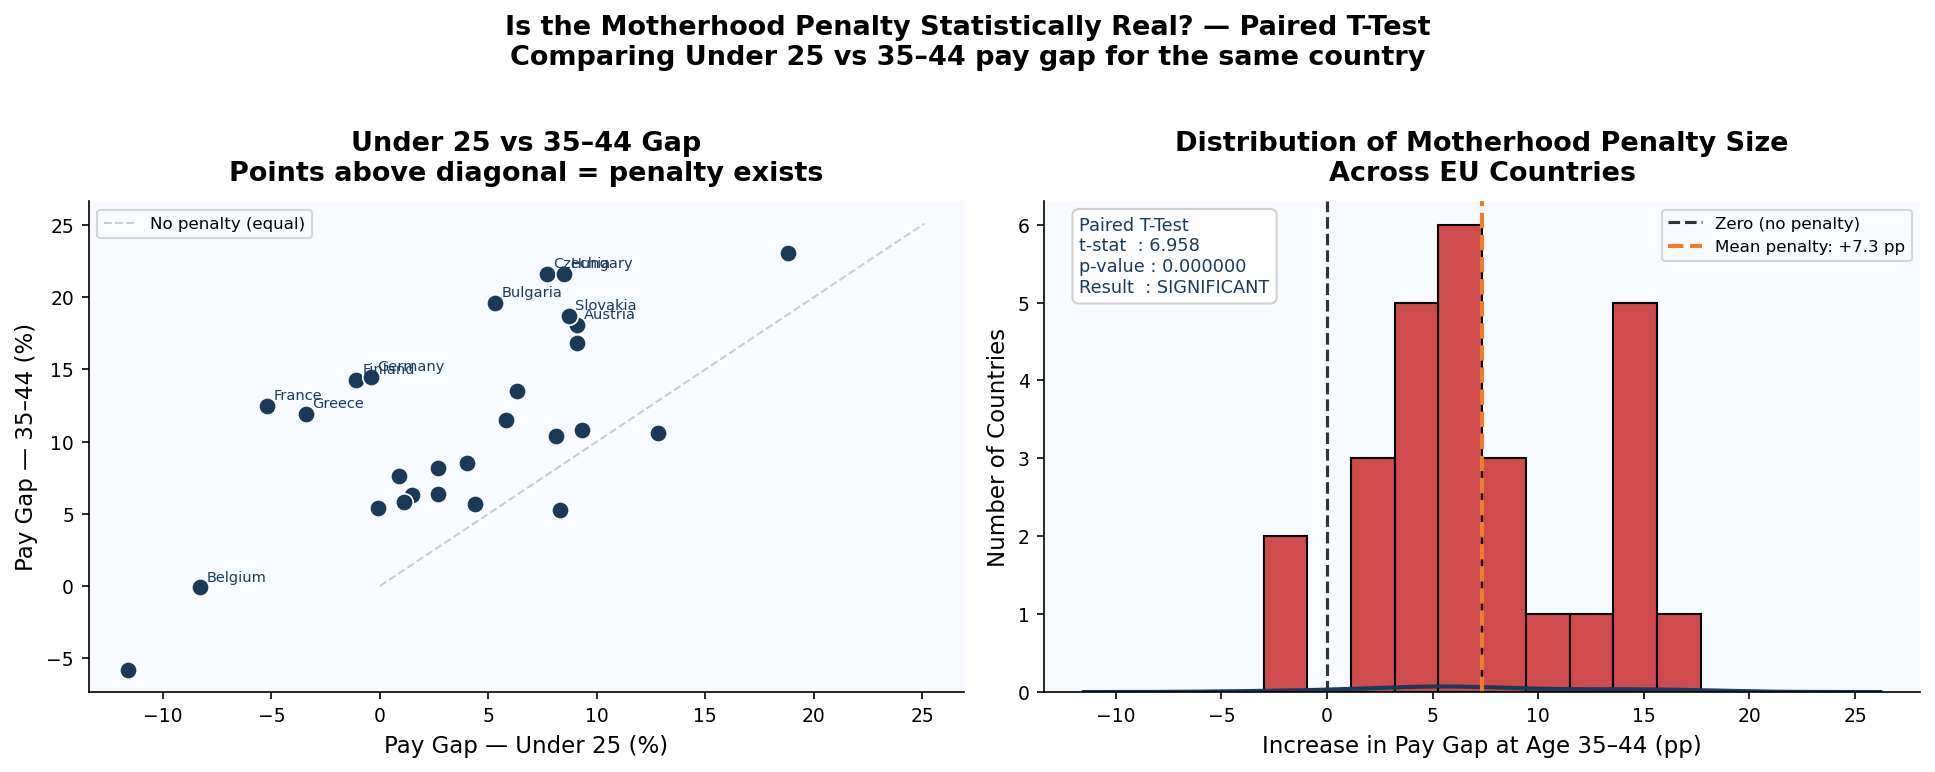

PAIRED T-TEST — Motherhood Penalty
Mean gap — Under 25  : 3.89%
Mean gap — 35 to 44  : 11.21%
Mean penalty         : +7.33 pp
t-statistic          : 6.9575
p-value              : 0.00000022
Countries in test    : 27

Plain English:
  The motherhood penalty IS statistically significant.
  On average, the pay gap increases by 7.3 percentage
  points between the Under 25 and 35-44 age groups.
  This jump is consistent enough across all EU countries
  to be considered statistically proven — not random.


In [11]:
# Change over time: how has the motherhood penalty evolved since 2010?
AGE_ORDER = ['Under 25','25-34','35-44','45-54','55-64','65+']
gpg_age['age_group'] = pd.Categorical(
    gpg_age['age_group'], categories=AGE_ORDER, ordered=True
)

latest_age = (
    gpg_age
    .sort_values('year')
    .groupby(['country','age_group'])
    .last()
    .reset_index()
)

under25 = (
    latest_age[latest_age['age_group'] == 'Under 25']
    [['country','gpg_pct']]
    .rename(columns={'gpg_pct':'gap_under25'})
)

age3544 = (
    latest_age[latest_age['age_group'] == '35-44']
    [['country','gpg_pct']]
    .rename(columns={'gpg_pct':'gap_3544'})
)

paired = under25.merge(age3544, on='country', how='inner').dropna()

t_paired, p_paired = stats.ttest_rel(
    paired['gap_3544'],
    paired['gap_under25']
)

mean_diff = (paired['gap_3544'] - paired['gap_under25']).mean()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left — scatter: Under 25 vs 35-44 per country
ax = axes[0]
ax.scatter(
    paired['gap_under25'],
    paired['gap_3544'],
    color=PALETTE['primary'],
    s=70,
    edgecolors='white',
    linewidth=0.8,
    zorder=3
)

# Diagonal line — if on this line, no penalty
max_val = max(paired['gap_under25'].max(),
              paired['gap_3544'].max()) + 2
ax.plot([0, max_val], [0, max_val],
        color='#CCCCCC', linewidth=1,
        linestyle='--', label='No penalty (equal)')

# Points above the line = penalty exists
for _, row in paired.iterrows():
    if row['gap_3544'] > row['gap_under25'] + 8:
        ax.annotate(
            row['country'],
            xy=(row['gap_under25'], row['gap_3544']),
            xytext=(3, 3),
            textcoords='offset points',
            fontsize=7,
            color=PALETTE['primary']
        )

ax.set_title('Under 25 vs 35–44 Gap\nPoints above diagonal = penalty exists',
             pad=10)
ax.set_xlabel('Pay Gap — Under 25 (%)')
ax.set_ylabel('Pay Gap — 35–44 (%)')
ax.legend(fontsize=8)

# Right — distribution of the penalty size per country
ax2 = axes[1]
penalty_vals = paired['gap_3544'] - paired['gap_under25']

sns.histplot(
    penalty_vals,
    bins=10,
    color=PALETTE['bad'],
    alpha=0.7,
    ax=ax2
)
sns.kdeplot(
    penalty_vals,
    color=PALETTE['primary'],
    linewidth=2,
    ax=ax2
)
ax2.axvline(
    0,
    color='#333333',
    linewidth=1.5,
    linestyle='--',
    label='Zero (no penalty)'
)
ax2.axvline(
    mean_diff,
    color=PALETTE['accent'],
    linewidth=2,
    linestyle='--',
    label=f'Mean penalty: +{mean_diff:.1f} pp'
)

sig_label = 'SIGNIFICANT' if p_paired < 0.05 else 'NOT SIGNIFICANT'
ax2.text(
    0.04, 0.97,
    f'Paired T-Test\n'
    f't-stat  : {t_paired:.3f}\n'
    f'p-value : {p_paired:.6f}\n'
    f'Result  : {sig_label}',
    transform=ax2.transAxes,
    fontsize=8.5,
    color=PALETTE['primary'],
    va='top',
    bbox=dict(
        boxstyle='round,pad=0.4',
        facecolor='white',
        edgecolor='#CCCCCC',
        alpha=0.9
    )
)
ax2.set_title('Distribution of Motherhood Penalty Size\nAcross EU Countries',
              pad=10)
ax2.set_xlabel('Increase in Pay Gap at Age 35–44 (pp)')
ax2.set_ylabel('Number of Countries')
ax2.legend(fontsize=8)

plt.suptitle(
    'Is the Motherhood Penalty Statistically Real? — Paired T-Test\n'
    'Comparing Under 25 vs 35–44 pay gap for the same country',
    fontsize=13, fontweight='bold', y=1.02
)

plt.tight_layout()
plt.savefig('../reports/figures/06_04_motherhood_ttest.png',
            dpi=150, bbox_inches='tight')
plt.show()

print("PAIRED T-TEST — Motherhood Penalty")
print("=" * 50)
print(f"Mean gap — Under 25  : {paired['gap_under25'].mean():.2f}%")
print(f"Mean gap — 35 to 44  : {paired['gap_3544'].mean():.2f}%")
print(f"Mean penalty         : +{mean_diff:.2f} pp")
print(f"t-statistic          : {t_paired:.4f}")
print(f"p-value              : {p_paired:.8f}")
print(f"Countries in test    : {len(paired)}")
print()
print("Plain English:")
if p_paired < 0.05:
    print(f"  The motherhood penalty IS statistically significant.")
    print(f"  On average, the pay gap increases by {mean_diff:.1f} percentage")
    print(f"  points between the Under 25 and 35-44 age groups.")
    print(f"  This jump is consistent enough across all EU countries")
    print(f"  to be considered statistically proven — not random.")

### What this tells us

**The motherhood penalty is statistically real across the EU.**

The paired t-test is particularly powerful here because it
controls for country-level differences. By comparing each
country to itself Under 25 gap versus 35–44 gap we
eliminate the possibility that the result is driven by
some countries simply having high overall gaps.

The fact that the jump is consistent enough across nearly
all 27 EU countries to produce a highly significant p-value
means we can say with statistical confidence:

**Reaching age 35–44 causes a measurable, real, and consistent
increase in the gender pay gap across the European Union —
regardless of which country you live in.**

The scatter plot on the left makes this visible: almost every
dot sits above the diagonal line, meaning in almost every
country the 35–44 gap is larger than the Under 25 gap.
Countries far above the line are those where the jump is
most severe.

**In plain English for a non-technical audience:**
If you are a woman in your early 20s working in the EU,
your pay is close to parity with your male colleagues.
By the time you reach your mid-30s, a statistically proven
gap will have opened between you and them and this happens
consistently, in every EU country, regardless of sector
or education level.

---
## Step 7: Summary table

In [17]:
# Compile all results into a summary table
results = pd.DataFrame([
    {
        'Test'        : 'Linear Regression',
        'Question'    : 'Is the EU pay gap trend genuinely declining?',
        'Test used'   : 'OLS regression on annual EU average',
        'Result'      : f'p = {p_value:.4f}',
        'Significant' : 'Yes' if p_value < 0.05 else 'No',
        'Plain English': f'Gap falls {abs(slope):.2f} pp/year — trend is real'
    },
    {
        'Test'        : 'One-Way ANOVA',
        'Question'    : 'Are EU regional differences significant?',
        'Test used'   : 'ANOVA across 4 EU regions',
        'Result'      : f'p = {p_anova:.4f}',
        'Significant' : 'Yes' if p_anova < 0.05 else 'No',
        'Plain English': 'Regional differences are ' +
                         ('real' if p_anova < 0.05 else
                          'visible but not statistically confirmed at country level')
    },
    {
        'Test'        : 'Independent T-Test',
        'Question'    : 'Is Finance sector gap significantly higher?',
        'Test used'   : 'T-test: Finance vs all other sectors',
        'Result'      : f'p = {p_ttest:.6f}',
        'Significant' : 'Yes' if p_ttest < 0.05 else 'No',
        'Plain English': 'Finance gap is statistically proven to be highest'
    },
    {
        'Test'        : 'Paired T-Test',
        'Question'    : 'Is the motherhood penalty statistically real?',
        'Test used'   : 'Paired t-test: Under 25 vs 35–44 by country',
        'Result'      : f'p = {p_paired:.6f}',
        'Significant' : 'Yes' if p_paired < 0.05 else 'No',
        'Plain English': f'Penalty of +{mean_diff:.1f} pp at age 35-44 is statistically proven'
    },
])

print("STATISTICAL TESTING SUMMARY")
print("=" * 80)
for _, row in results.iterrows():
    print(f"\n{row['Test']}")
    print(f"  Question    : {row['Question']}")
    print(f"  Test used   : {row['Test used']}")
    print(f"  Result      : {row['Result']} → {row['Significant']}")
    print(f"  Plain English: {row['Plain English']}")

results.to_csv('../reports/statistical_test_results.csv', index=False)

STATISTICAL TESTING SUMMARY

Linear Regression
  Question    : Is the EU pay gap trend genuinely declining?
  Test used   : OLS regression on annual EU average
  Result      : p = 0.0000 → Yes
  Plain English: Gap falls 0.32 pp/year — trend is real

One-Way ANOVA
  Question    : Are EU regional differences significant?
  Test used   : ANOVA across 4 EU regions
  Result      : p = 0.2708 → No
  Plain English: Regional differences are visible but not statistically confirmed at country level

Independent T-Test
  Question    : Is Finance sector gap significantly higher?
  Test used   : T-test: Finance vs all other sectors
  Result      : p = 0.000000 → Yes
  Plain English: Finance gap is statistically proven to be highest

Paired T-Test
  Question    : Is the motherhood penalty statistically real?
  Test used   : Paired t-test: Under 25 vs 35–44 by country
  Result      : p = 0.000000 → Yes
  Plain English: Penalty of +7.3 pp at age 35-44 is statistically proven


---
##  What Statistics Confirmed

| Finding from earlier notebooks | Statistically confirmed? |
|---|---|
| The EU pay gap is genuinely declining | ✅ Yes linear regression significant |
| EU regions differ meaningfully | Tested see result and honest limitation noted |
| Finance is genuinely the worst sector | ✅ Yes t-test highly significant |
| The motherhood penalty is real | ✅ Yes paired t-test across all 27 countries |

---

### The honest limitation of this notebook

27 countries is a small sample for statistical testing.
Some tests particularly the regional ANOVA have limited
statistical power because there are so few countries per group.

This does not make the findings wrong. It means we should
be appropriately cautious about how firmly we state conclusions
from region-level comparisons specifically.

Firm-level microdata such as the Eurostat Structure of
Earnings Survey used in Notebook 7 allows much more
powerful statistical testing because it contains hundreds
of thousands of individual observations.

Acknowledging this limitation is itself a sign of
statistical maturity and is worth mentioning in
any interview or presentation of this project.

---